# Preprocessing

## Imports and .env

In [1]:
from openai import OpenAI
import os
import pandas as pd
import json
import numpy as np
from dotenv import load_dotenv
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, balanced_accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()
openai_key = os.getenv("OPENAI_API_KEY")

## Open labeled data

In [2]:
df = pd.read_csv("../data/labeled/subset_balanced_750.csv")
print(f"Loaded {len(df)} comments")
print(df.groupby(["language", "label"]).size().unstack(fill_value=0).reindex(["DE","EN","ES","FR"]))

Loaded 750 comments
label     NEGATIVE  NEUTRAL  POSITIVE
language                             
DE              97       97        97
EN              65       65        65
ES              60       60        60
FR              28       28        28


# GPT-4o

## Create GPT Connection and predict data

In [3]:
from openai import OpenAI

client = OpenAI(api_key=openai_key)

def send_message_to_gpt(player, comment):

    json_format = {
        "sentiment_score": 0,
        "sentiment": "NEUTRAL",
        "explanation": "example"
    }

    model_prompt = f"You are a linguistics expert and have been assigned to rate social media comments from soccer fans. In the following you will be given a name of a soccer player and a comment from a social media channel. Please rate it according to sentiment towards the Player. The score should be in a range from -1 to 1, where -1 is negative, 0 is neutral and 1 is positive. Please also consider whether the comment realy refers to the specified player and which part of the comment refers realy to the player. Also note the emojis. please give me a sentiment score (-1 to 1), a sentiment (NEGATIVE, NEUTRAL OR POSITIVE) and an explanation in JSON format exact like this: {json.dumps(json_format)}"

    completion = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": model_prompt},
            {
                "role": "user",
                "content": f"Player: {player}, Comment: {comment}"
            }
        ],
        response_format={"type": "json_object"}
    )

    return completion

def analyze_sentiment(player, comment):
    completion = send_message_to_gpt(player=player, comment=comment)
    try:
        content = json.loads(completion.choices[0].message.content)
        return content["sentiment_score"], content["sentiment"], content["explanation"]
    except:
        print(completion.choices[0].message.content)
        return None, None, None

In [4]:
df["gpt_sentiment_score"], df["gpt_label"], df["gpt_explanation"] = zip(*df.apply(lambda row: analyze_sentiment(row["player"], row["comment"]), axis=1))

In [5]:
df.to_csv("../data/labeled/subset_balanced_750_predictions.csv", index=False)

## Performance Metrics

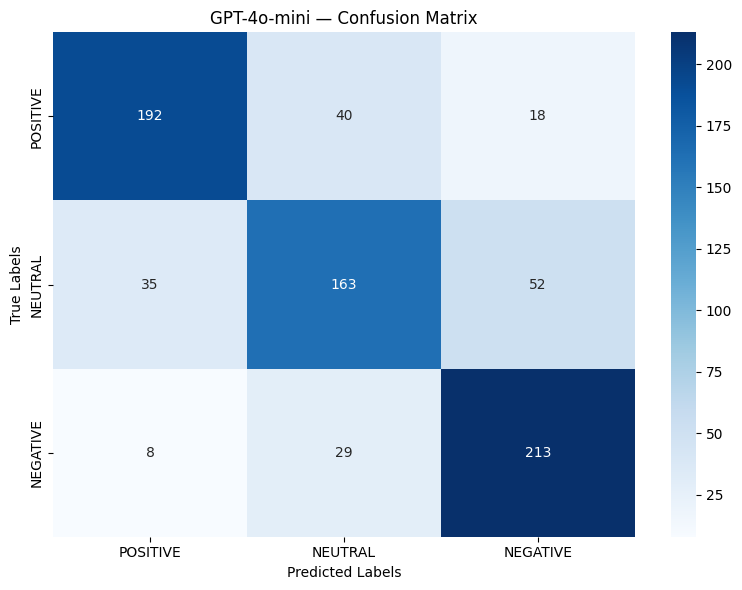

In [6]:
LABELS = ["POSITIVE", "NEUTRAL", "NEGATIVE"]

cm = confusion_matrix(df["label"], df["gpt_label"], labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("GPT-4o-mini — Confusion Matrix")
plt.tight_layout()
plt.show()

In [7]:
accuracy = accuracy_score(df["label"], df["gpt_label"])
balanced_accuracy = balanced_accuracy_score(df["label"], df["gpt_label"])
classification_metrics = classification_report(df["label"], df["gpt_label"], labels=LABELS)

print(f"Accuracy:          {accuracy:.2f}")
print(f"Balanced Accuracy: {balanced_accuracy:.2f}")
print("\nClassification Report:")
print(classification_metrics)

print("\nPer-Language Breakdown:")
for lang in ["DE", "EN", "ES", "FR"]:
    sub = df[df["language"] == lang]
    acc = accuracy_score(sub["label"], sub["gpt_label"])
    bal = balanced_accuracy_score(sub["label"], sub["gpt_label"])
    print(f"  {lang}  Accuracy: {acc:.2f}  Balanced Accuracy: {bal:.2f}  (n={len(sub)})")

Accuracy:          0.76
Balanced Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

    POSITIVE       0.82      0.77      0.79       250
     NEUTRAL       0.70      0.65      0.68       250
    NEGATIVE       0.75      0.85      0.80       250

    accuracy                           0.76       750
   macro avg       0.76      0.76      0.76       750
weighted avg       0.76      0.76      0.76       750


Per-Language Breakdown:
  DE  Accuracy: 0.71  Balanced Accuracy: 0.71  (n=291)
  EN  Accuracy: 0.76  Balanced Accuracy: 0.76  (n=195)
  ES  Accuracy: 0.81  Balanced Accuracy: 0.81  (n=180)
  FR  Accuracy: 0.81  Balanced Accuracy: 0.81  (n=84)


# XLM-T

In [2]:
df = pd.read_csv("../data/labeled/subset_balanced_750_predictions.csv")

In [3]:
from transformers import AutoModelForSequenceClassification
from transformers import TFAutoModelForSequenceClassification
from transformers import AutoTokenizer, AutoConfig
import numpy as np

/Users/kn3ule/code_projects/python/sentiment-analysis-football-scouting/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from transformers import pipeline
model_path = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
sentiment_task = pipeline("sentiment-analysis", model=model_path, tokenizer=model_path, use_fast=False)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.


In [5]:
# Funktion zur Anwendung der Sentiment-Analyse
def analyze_with_xlm_roberta(comment):
    result = sentiment_task(comment)[0]  # Das Ergebnis für den Kommentar
    label = result["label"].upper()  # Sentiment-Label: POSITIVE, NEGATIVE, NEUTRAL
    score = result["score"]  # Wahrscheinlichkeit (Confidence-Score)
    return score, label

In [6]:
df["xlm_roberta_score"], df["xlm_roberta_label"] = zip(
    *df["comment"].apply(analyze_with_xlm_roberta)
)

In [7]:
df.to_csv("../data/labeled/subset_balanced_750_predictions.csv", index=False)

## Performance Metrics

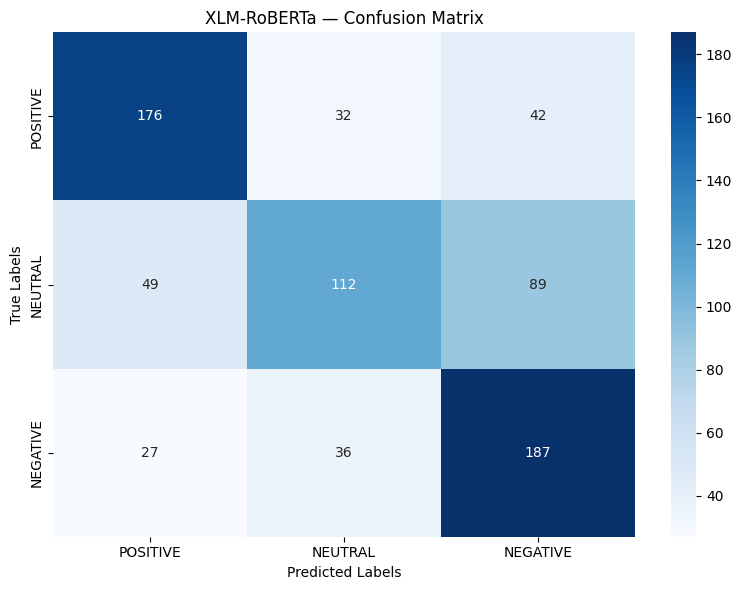

In [9]:
LABELS = ["POSITIVE", "NEUTRAL", "NEGATIVE"]
cm = confusion_matrix(df["label"], df["xlm_roberta_label"], labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("XLM-RoBERTa — Confusion Matrix")
plt.tight_layout()
plt.show()

In [10]:
accuracy = accuracy_score(df["label"], df["xlm_roberta_label"])
balanced_accuracy = balanced_accuracy_score(df["label"], df["xlm_roberta_label"])
classification_metrics = classification_report(df["label"], df["xlm_roberta_label"], labels=LABELS)

print(f"Accuracy:          {accuracy:.2f}")
print(f"Balanced Accuracy: {balanced_accuracy:.2f}")
print("\nClassification Report:")
print(classification_metrics)

print("\nPer-Language Breakdown:")
for lang in ["DE", "EN", "ES", "FR"]:
    sub = df[df["language"] == lang]
    acc = accuracy_score(sub["label"], sub["xlm_roberta_label"])
    bal = balanced_accuracy_score(sub["label"], sub["xlm_roberta_label"])
    print(f"  {lang}  Accuracy: {acc:.2f}  Balanced Accuracy: {bal:.2f}  (n={len(sub)})")

Accuracy:          0.63
Balanced Accuracy: 0.63

Classification Report:
              precision    recall  f1-score   support

    POSITIVE       0.70      0.70      0.70       250
     NEUTRAL       0.62      0.45      0.52       250
    NEGATIVE       0.59      0.75      0.66       250

    accuracy                           0.63       750
   macro avg       0.64      0.63      0.63       750
weighted avg       0.64      0.63      0.63       750


Per-Language Breakdown:
  DE  Accuracy: 0.61  Balanced Accuracy: 0.61  (n=291)
  EN  Accuracy: 0.60  Balanced Accuracy: 0.60  (n=195)
  ES  Accuracy: 0.68  Balanced Accuracy: 0.68  (n=180)
  FR  Accuracy: 0.70  Balanced Accuracy: 0.70  (n=84)


# Vader

In [11]:
from translate import Translator
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Translator initialisieren
translator = Translator(to_lang="en")
analyzer = SentimentIntensityAnalyzer()

In [12]:
# Funktion zur Anwendung der Sentiment-Analyse mit VADER
def analyze_with_vader(comment):
    # Übersetzung ins Englische
    translated_text = translator.translate(comment)
    scores = analyzer.polarity_scores(translated_text)
    compound_score = scores["compound"]  # VADER-Compound-Score (-1 bis 1)
    # Klassifizierung basierend auf Compound-Score
    if compound_score >= 0.05:
        sentiment = "POSITIVE"
    elif compound_score <= -0.05:
        sentiment = "NEGATIVE"
    else:
        sentiment = "NEUTRAL"
    return compound_score, sentiment

In [13]:
df["vader_score"], df["vader_label"] = zip(
    *df["comment"].apply(analyze_with_vader)
)
df.to_csv("../data/labeled/subset_balanced_750_predictions.csv", index=False)

## Performance Metrics

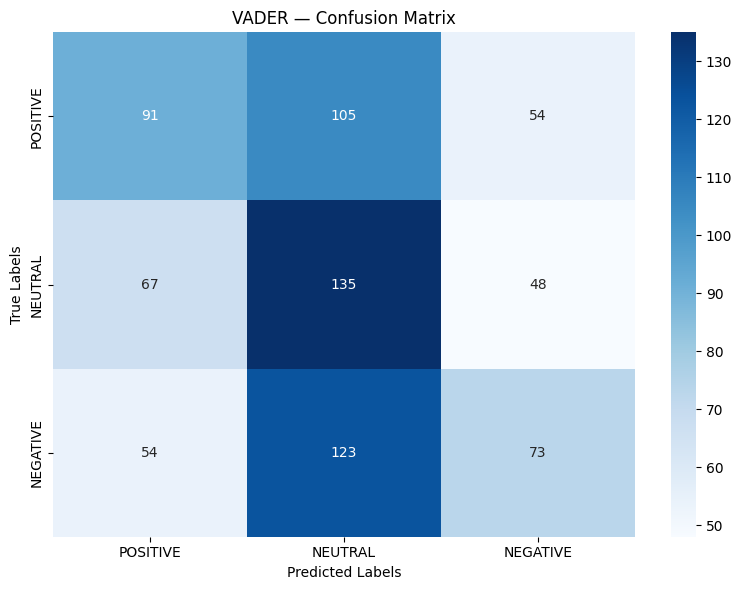

In [14]:
cm = confusion_matrix(df["label"], df["vader_label"], labels=LABELS)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("VADER — Confusion Matrix")
plt.tight_layout()
plt.show()

In [15]:
accuracy = accuracy_score(df["label"], df["vader_label"])
balanced_accuracy = balanced_accuracy_score(df["label"], df["vader_label"])
classification_metrics = classification_report(df["label"], df["vader_label"], labels=LABELS)

print(f"Accuracy:          {accuracy:.2f}")
print(f"Balanced Accuracy: {balanced_accuracy:.2f}")
print("\nClassification Report:")
print(classification_metrics)

print("\nPer-Language Breakdown:")
for lang in ["DE", "EN", "ES", "FR"]:
    sub = df[df["language"] == lang]
    acc = accuracy_score(sub["label"], sub["vader_label"])
    bal = balanced_accuracy_score(sub["label"], sub["vader_label"])
    print(f"  {lang}  Accuracy: {acc:.2f}  Balanced Accuracy: {bal:.2f}  (n={len(sub)})")

Accuracy:          0.40
Balanced Accuracy: 0.40

Classification Report:
              precision    recall  f1-score   support

    POSITIVE       0.43      0.36      0.39       250
     NEUTRAL       0.37      0.54      0.44       250
    NEGATIVE       0.42      0.29      0.34       250

    accuracy                           0.40       750
   macro avg       0.41      0.40      0.39       750
weighted avg       0.41      0.40      0.39       750


Per-Language Breakdown:
  DE  Accuracy: 0.36  Balanced Accuracy: 0.36  (n=291)
  EN  Accuracy: 0.45  Balanced Accuracy: 0.45  (n=195)
  ES  Accuracy: 0.44  Balanced Accuracy: 0.44  (n=180)
  FR  Accuracy: 0.32  Balanced Accuracy: 0.32  (n=84)


# Comparative Analysis

=== Overall Performance ===
             Accuracy  Balanced Accuracy
Model                                   
GPT-4o-mini     0.757              0.757
XLM-RoBERTa     0.633              0.633
VADER           0.399              0.399

=== Balanced Accuracy per Language ===
          GPT-4o-mini  XLM-RoBERTa  VADER
Language                                 
DE              0.711        0.608  0.361
EN              0.759        0.600  0.446
ES              0.806        0.678  0.444
FR              0.810        0.702  0.321


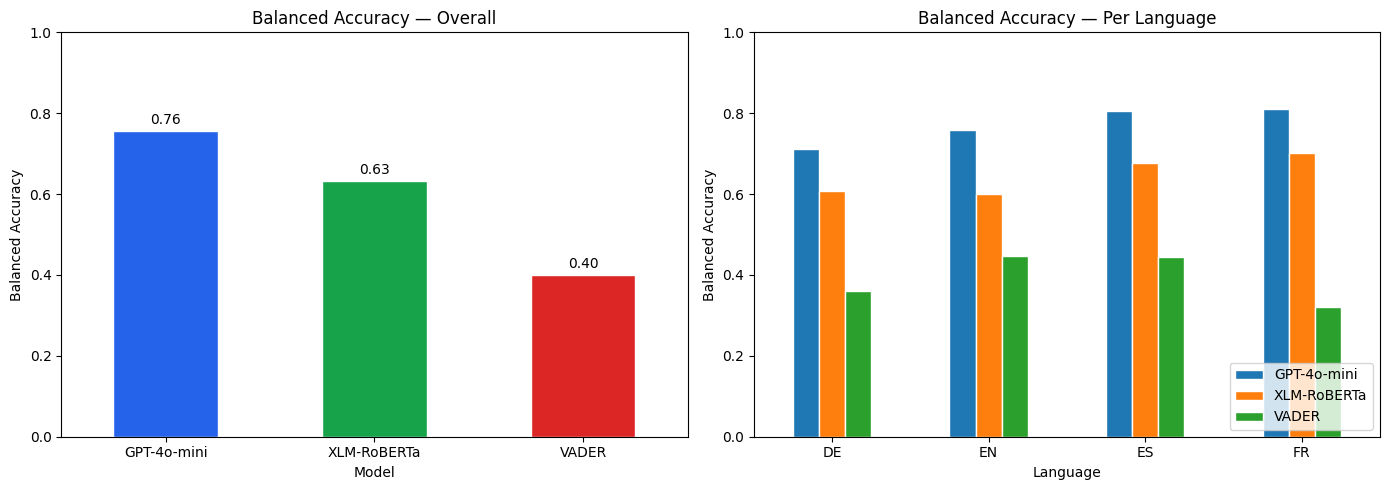

In [16]:
df = pd.read_csv("../data/labeled/subset_balanced_750_predictions.csv")

models = {
    "GPT-4o-mini": "gpt_label",
    "XLM-RoBERTa": "xlm_roberta_label",
    "VADER":        "vader_label",
}

# ── Overall comparison table ───────────────────────────────────────────────────
rows = []
for model_name, col in models.items():
    acc = accuracy_score(df["label"], df[col])
    bal = balanced_accuracy_score(df["label"], df[col])
    rows.append({"Model": model_name, "Accuracy": round(acc, 3), "Balanced Accuracy": round(bal, 3)})

summary = pd.DataFrame(rows).set_index("Model")
print("=== Overall Performance ===")
print(summary.to_string())

# ── Per-language comparison ────────────────────────────────────────────────────
print("\n=== Balanced Accuracy per Language ===")
lang_rows = []
for lang in ["DE", "EN", "ES", "FR"]:
    sub = df[df["language"] == lang]
    row = {"Language": lang}
    for model_name, col in models.items():
        row[model_name] = round(balanced_accuracy_score(sub["label"], sub[col]), 3)
    lang_rows.append(row)

lang_df = pd.DataFrame(lang_rows).set_index("Language")
print(lang_df.to_string())

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

summary["Balanced Accuracy"].plot(kind="bar", ax=axes[0], color=["#2563eb","#16a34a","#dc2626"], edgecolor="white")
axes[0].set_title("Balanced Accuracy — Overall")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Balanced Accuracy")
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)

lang_df.plot(kind="bar", ax=axes[1], edgecolor="white")
axes[1].set_title("Balanced Accuracy — Per Language")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("Balanced Accuracy")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()
# Comparative Analysis